In [1]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import datetime
import networkx as nx
from itertools import combinations
import pycountry
import plotly.graph_objects as go

# Loading and Cleaning

In [2]:

# --- Data Loading & Cleaning for Flattened OpenAlex ---
def load_and_clean_your_csv(file_path):
    """
    Cleans the flattened OpenAlex CSV structure found in your research01 file.
    """
    df = pd.read_csv(file_path)
    
    # 1. Standardize Numeric Columns
    df['publication_year'] = pd.to_numeric(df['publication_year'], errors='coerce')
    df['cited_by_count'] = pd.to_numeric(df['cited_by_count'], errors='coerce').fillna(0)
    
    # 2. Extract Primary Author (takes the first name before the first '|')
    def get_primary_author(name_str):
        if pd.isna(name_str): return "Unknown"
        return str(name_str).split('|')[0]

    # 3. Handle Topics/Keywords (using the 'primary_topic.display_name' column)
    # Note: If you want to use the full topic string, we keep it as is.
    df['primary_author'] = df['authorships.author.display_name'].apply(get_primary_author)
    
    return df

# Load your specific file
df_clean = load_and_clean_your_csv('research01_works-csv-epopDs4cfD3FyuN8piis3A.csv')


In [3]:
df_clean.head()

,id,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,cited_by_count,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,primary_author
0,https://openalex.org/W2109101401,David Pisinger|Stefan Røpke,https://openalex.org/A5081910021|https://opena...,https://orcid.org/0000-0001-7695-9662|https://...,DK|DK,University of Copenhagen|University of Copenhagen,https://openalex.org/I124055696|https://openal...,True|False,NaN,1360,...,closed,Computers & Operations Research,https://openalex.org/S173256270,0305-0548,journal,Vehicle Routing Optimization Methods,2005-10-25,2005.0,article,David Pisinger
1,https://openalex.org/W2116675171,Olli Bräysy|Michel Gendreau,https://openalex.org/A5014631682|https://opena...,|https://orcid.org/0000-0002-9262-3648,FI|CA,University of Jyväskylä|Université de Montréal,https://openalex.org/I94722563|https://openale...,True|False,NaN,817,...,closed,Transportation Science,https://openalex.org/S130252234,0041-1655,journal,Vehicle Routing Optimization Methods,2005-02-01,2005.0,article,Olli Bräysy
2,https://openalex.org/W2158000627,J-F Cordeau|G Laporte|Aurelién Mercier,https://openalex.org/A5059523142|https://opena...,||https://orcid.org/0000-0003-4332-5879,CA|CA|CA,HEC Montréal|HEC Montréal|HEC Montréal,https://openalex.org/I108192572|https://openal...,False|True|True,NaN,882,...,closed,Journal of the Operational Research Society,https://openalex.org/S169988927,0160-5682,journal,Vehicle Routing Optimization Methods,2001-08-01,2001.0,article,J-F Cordeau
3,https://openalex.org/W2084977713,Éric D. Taillard|Philippe Badeau|Michel Gendre...,https://openalex.org/A5071782451|https://opena...,||https://orcid.org/0000-0002-9262-3648||https...,CH|FR|CA|CA|CA,Dalle Molle Institute for Artificial Intellige...,https://openalex.org/I2614128279|https://opena...,True|False|False|False|False,NaN,924,...,green,Transportation Science,https://openalex.org/S130252234,0041-1655,journal,Vehicle Routing Optimization Methods,1997-05-01,1997.0,article,Éric D. Taillard
4,https://openalex.org/W1975828823,Jean-Fran�ois Cordeau|Michel Gendreau|Gilbert ...,https://openalex.org/A5008962425|https://opena...,|https://orcid.org/0000-0002-9262-3648|https:/...,CA|CA|CA,Université de Montréal|Université de Montréal|...,https://openalex.org/I70931966|https://openale...,False|False|True,NaN,821,...,closed,Networks,https://openalex.org/S191798613,0028-3045,journal,Vehicle Routing Optimization Methods,1997-09-01,1997.0,article,Jean-Fran�ois Cordeau


In [4]:
# --- Rigorous cleaning (accents and extrange characters) --- #

def rigorous_clean(text):
    if not isinstance(text, str):
        return text
    
    # 1. Remove the '' and non-printable artifacts
    # This encodes to ASCII and ignores anything it can't translate
    text = text.encode("ascii", "ignore").decode("ascii")
    
    # 2. Normalize to remove accents correctly
    nksel = unicodedata.normalize('NFKD', text)
    clean_text = "".join([c for c in nksel if not unicodedata.combining(c)])
    
    # 3. Use Regex to keep only letters, numbers, pipes (for your separators), and basic punctuation
    # This removes the "weird elements" and extra spaces between letters
    clean_text = re.sub(r'[^a-zA-Z0-9\s|.\-]', '', clean_text)
    
    # 4. Collapse multiple spaces into one
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    
    return clean_text

# Apply to your columns
cols_to_fix = ['authorships.author.display_name', 'display_name', 'primary_topic.display_name']

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(rigorous_clean)

print("Rigorous cleaning finished. No more squares or extra spaces.")

Rigorous cleaning finished. No more squares or extra spaces.


In [5]:
df_clean.head()

,id,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,cited_by_count,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,primary_author
0,https://openalex.org/W2109101401,David Pisinger|Stefan Rpke,https://openalex.org/A5081910021|https://opena...,https://orcid.org/0000-0001-7695-9662|https://...,DK|DK,University of Copenhagen|University of Copenhagen,https://openalex.org/I124055696|https://openal...,True|False,NaN,1360,...,closed,Computers & Operations Research,https://openalex.org/S173256270,0305-0548,journal,Vehicle Routing Optimization Methods,2005-10-25,2005.0,article,David Pisinger
1,https://openalex.org/W2116675171,Olli Brysy|Michel Gendreau,https://openalex.org/A5014631682|https://opena...,|https://orcid.org/0000-0002-9262-3648,FI|CA,University of Jyväskylä|Université de Montréal,https://openalex.org/I94722563|https://openale...,True|False,NaN,817,...,closed,Transportation Science,https://openalex.org/S130252234,0041-1655,journal,Vehicle Routing Optimization Methods,2005-02-01,2005.0,article,Olli Bräysy
2,https://openalex.org/W2158000627,J-F Cordeau|G Laporte|Aurelin Mercier,https://openalex.org/A5059523142|https://opena...,||https://orcid.org/0000-0003-4332-5879,CA|CA|CA,HEC Montréal|HEC Montréal|HEC Montréal,https://openalex.org/I108192572|https://openal...,False|True|True,NaN,882,...,closed,Journal of the Operational Research Society,https://openalex.org/S169988927,0160-5682,journal,Vehicle Routing Optimization Methods,2001-08-01,2001.0,article,J-F Cordeau
3,https://openalex.org/W2084977713,ric D. Taillard|Philippe Badeau|Michel Gendrea...,https://openalex.org/A5071782451|https://opena...,||https://orcid.org/0000-0002-9262-3648||https...,CH|FR|CA|CA|CA,Dalle Molle Institute for Artificial Intellige...,https://openalex.org/I2614128279|https://opena...,True|False|False|False|False,NaN,924,...,green,Transportation Science,https://openalex.org/S130252234,0041-1655,journal,Vehicle Routing Optimization Methods,1997-05-01,1997.0,article,Éric D. Taillard
4,https://openalex.org/W1975828823,Jean-Franois Cordeau|Michel Gendreau|Gilbert L...,https://openalex.org/A5008962425|https://opena...,|https://orcid.org/0000-0002-9262-3648|https:/...,CA|CA|CA,Université de Montréal|Université de Montréal|...,https://openalex.org/I70931966|https://openale...,False|False|True,NaN,821,...,closed,Networks,https://openalex.org/S191798613,0028-3045,journal,Vehicle Routing Optimization Methods,1997-09-01,1997.0,article,Jean-Fran�ois Cordeau


# Function Creation

In [6]:

# --- Production Over Time ---
def plot_production_trends(df):
    # Filter years to match your study range (e.g., 2015-2025)
    yearly_counts = df[df['publication_year'] >= 2000]['publication_year'].value_counts().sort_index()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=yearly_counts.index.astype(int), y=yearly_counts.values, color='gold')
    plt.title('Documents per Year (VRP Review)', fontsize=16)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Number of Documents', fontsize=14)
    plt.xticks(fontsize=12) # Increases size of the numbers on the X-axis
    plt.yticks(fontsize=12) # Increases size of the Author Names on the Y-axis
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [7]:
## -- Get country name ---##
def get_country_name(code):
    try:
        # Translates 'MX' -> 'Mexico', 'CN' -> 'China', etc.
        return pycountry.countries.get(alpha_2=code).name
    except:
        return code # Returns original code if translation fails


In [8]:
# --- Filtered Topic Analysis ---
def plot_real_trends(df):
    """
    Excludes the broad search terms to see the underlying application 
    areas for Hybrid Augmented Intelligence.
    """
    # 1. Define the terms to remove (VRP and its obvious synonyms)
    exclude_list = [
        'vehicle routing problem', 
        'vrp', 
        'vehicle routing optimization methods',
        'routing optimization'
    ]
    
    # 2. Get the value counts of the primary topic column
    topic_counts = df['primary_topic.display_name'].value_counts()
    
    # 3. Filter the series using a negative regex match
    # This keeps only topics that DO NOT contain our exclusion terms
    pattern = '|'.join(exclude_list)
    filtered_topics = topic_counts[~topic_counts.index.str.contains(pattern, case=False, na=False)]
    
    # 4. Grab the top 10 for the visualization
    top_10_real = filtered_topics.head(10)
    
    # 5. Visualization
    plt.figure(figsize=(15, 6))
    sns.barplot(x=top_10_real.values, y=top_10_real.index, palette='magma')
    plt.title('Top 10 Research Domains (VRP Terms Removed)', fontsize=14)
    plt.xlabel('Number of Articles')
    plt.ylabel('')
    plt.xticks(fontsize=12) # Increases size of the numbers on the X-axis
    plt.yticks(fontsize=12) # Increases size of the Author Names on the Y-axis
    plt.tight_layout()
    plt.show()



In [9]:
# --- Top Cited Articles (Identification of Influential Works) ---
def show_top_cited(df):
    """Shows the most influential papers for your review."""
    top_papers = df[['display_name', 'primary_author', 'publication_year', 'cited_by_count']].sort_values(by='cited_by_count', ascending=False).head(10)
    return top_papers


In [10]:
##--- Plot top stats ----

def plot_top_stats(df, category='author', metric='publications', top_n=10, 
                    citation_col='cited_by_count', separator='|'):
    """
    Unified function adjusted for your specific research01 dataset column names.
    """
    
    # 1. Map generic categories to YOUR specific DataFrame column names
    column_map = {
        'author': 'authorships.author.display_name',
        'institution': 'authorships.institutions.display_name',
        'country': 'authorships.countries'  
    }
    
    target_col = column_map.get(category.lower())
    
    if not target_col or target_col not in df.columns:
        print(f"Error: Category '{category}' invalid or column '{target_col}' missing.")
        return

    # 2. Pre-process: Copy only needed columns
    cols_needed = [target_col]
    if metric == 'citations':
        cols_needed.append(citation_col)
    df_temp = df[cols_needed].copy()
    
    # 3. Clean and Explode (Split values by the pipe '|')
    df_temp[target_col] = df_temp[target_col].fillna('').astype(str).str.split(separator)
    exploded = df_temp.explode(target_col)

    # 4. Rigorous Cleaning
    if category == 'author':
        exploded[target_col] = exploded[target_col].apply(rigorous_clean)
    elif category == 'country':
        # Translate codes to names
        exploded[target_col] = exploded[target_col].str.strip().apply(get_country_name)
    else:
        exploded[target_col] = exploded[target_col].str.strip()

    # Remove garbage strings (length <= 1)
    exploded = exploded[exploded[target_col].str.len() > 1]
    
    # 5. Calculation Logic
    if metric == 'publications':
        top_data = exploded.groupby(target_col).size().sort_values(ascending=False).head(top_n)
        title_text = f'Top {top_n} {category.capitalize()}s (by Publication Count)'
        x_label = 'Number of Documents'
        palette = 'viridis'

    elif metric == 'citations':
        top_data = exploded.groupby(target_col)[citation_col].sum().sort_values(ascending=False).head(top_n)
        title_text = f'Top {top_n} {category.capitalize()}s (by Total Citations)'
        x_label = 'Total Citations'
        palette = 'rocket'

    # 6. Visualization
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_data.values, y=top_data.index, palette=palette)
    
    plt.title(title_text, fontsize=16)
    plt.xlabel(x_label, fontsize=14)
    #plt.ylabel(category.capitalize(), fontsize=14)
    plt.ylabel('')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return top_data

In [11]:
# --- Filtered database by the last n years ----#
def filter_by_last_n_years(df, n_years):
    """
    Filters the dataframe to include only articles from the last n_years.
    Useful for defining the '2015-2025' timeframe for your review.
    """
    # 1. Ensure publication_year is numeric
    df['publication_year'] = pd.to_numeric(df['publication_year'], errors='coerce')
    
    # 2. Determine the reference year (Current year is 2026)
    current_year = 2026 
    start_year = current_year - n_years
    
    # 3. Create the filtered dataframe
    filtered_df = df[df['publication_year'] >= start_year].copy()
    
    print(f"Original articles: {len(df)}")
    print(f"Articles from {start_year} to {current_year}: {len(filtered_df)}")
    
    return filtered_df

In [12]:
## --- Author clusters ----#
def analyze_author_clusters(df, authors_column, min_collaborations=4, separator='|', 
                            grid_rows=2, grid_cols=2, node_size=500, font_size=10, 
                            edge_width_scale=0.5):
    """
    Plots the top author clusters in a grid layout.
    
    Parameters:
    - df: DataFrame containing the data.
    - authors_column: Name of the column with authors.
    - min_collaborations: Minimum shared papers to create a link.
    - separator: Character separating authors (e.g., '|' or ';').
    - grid_rows, grid_cols: Dimensions of the subplot grid (e.g., 2x2 = top 4 clusters).
    - node_size: Visual size of the author bubbles.
    - font_size: Size of the author names.
    - edge_width_scale: Multiplier for edge thickness.
    """
    
    # --- 1. BUILD THE GRAPH ---
    G = nx.Graph()
    
    # Iterate through publications
    for authors_str in df[authors_column].dropna():
        # Split and clean author names
        authors = [a.strip() for a in str(authors_str).split(separator) if a.strip()]
        
        # Create edges for every pair of co-authors
        if len(authors) > 1:
            for u, v in combinations(authors, 2):
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)

    # --- 2. FILTER & SORT CLUSTERS ---
    # Keep only edges that meet the minimum collaboration threshold
    strong_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= min_collaborations]
    G_filtered = G.edge_subgraph(strong_edges).copy()
    
    # Get all connected components (clusters) and sort them by size (largest first)
    # This ensures we prioritize the "most collaborative" groups
    clusters = sorted(nx.connected_components(G_filtered), key=len, reverse=True)
    
    if not clusters:
        print(f"No collaborations found with >= {min_collaborations} shared papers.")
        return

    # --- 3. CREATE THE GRID PLOT ---
    num_plots = grid_rows * grid_cols
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 6, grid_rows * 6))
    
    # Flatten axes array for easy iteration (handles 1x1, 1xN, NxN cases)
    if grid_rows * grid_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    print(f"Found {len(clusters)} clusters. Showing the top {min(len(clusters), num_plots)}.")

    for i in range(num_plots):
        ax = axes[i]
        
        # If we run out of clusters, hide the empty subplot
        if i >= len(clusters):
            ax.axis('off')
            continue
            
        # Get the subgraph for this specific cluster
        cluster_nodes = clusters[i]
        sub_G = G_filtered.subgraph(cluster_nodes)
        
        # Layout: distinct shape for each cluster
        pos = nx.spring_layout(sub_G, k=0.5, seed=42)
        
        # Dynamic edge thickness based on collaboration count
        weights = [sub_G[u][v]['weight'] for u, v in sub_G.edges()]
        widths = [w * edge_width_scale for w in weights]
        
        # Draw the plot
        nx.draw_networkx_nodes(sub_G, pos, ax=ax, node_size=node_size, node_color='lightblue')
        nx.draw_networkx_edges(sub_G, pos, ax=ax, width=widths, alpha=0.5, edge_color='gray')
        nx.draw_networkx_labels(sub_G, pos, ax=ax, font_size=font_size, font_family="sans-serif")
        
        ax.set_title(f"Cluster #{i+1} ({len(cluster_nodes)} Authors)", fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---
# analyze_author_clusters(
#     df, 
#     authors_column='Authors', 
#     min_collaborations=5, 
#     separator='|',
#     grid_rows=2, 
#     grid_cols=2,   # This will show the top 4 biggest groups
#     node_size=600, 
#     font_size=8
# )

In [13]:
## --- Colaboration clusters --- ##
def analyze_category_clusters(df, category='author', min_shared=4, 
                               grid_rows=2, grid_cols=2, node_size=20, 
                               font_size=12, edge_width_scale=0.5):
    """
    Generalized function to plot collaboration clusters for Authors, Institutions, or Countries.
    """
    
    # 1. Map categories to your specific CSV columns
    column_map = {
        'author': 'authorships.author.display_name',
        'institution': 'authorships.institutions.display_name',
        'country': 'authorships.countries'
    }
    
    target_col = column_map.get(category.lower())
    if not target_col:
        print(f"Error: Category '{category}' not supported.")
        return

    # 2. Country name translation helper
    def translate_country(code):
        try: return pycountry.countries.get(alpha_2=code.strip()).name
        except: return code.strip()

    # 3. Build the Graph
    G = nx.Graph()
    
    for items_str in df[target_col].dropna():
        # Split and clean
        items = [i.strip() for i in str(items_str).split('|') if i.strip()]
        
        # Category-specific cleaning
        if category == 'author':
            items = [rigorous_clean(i) for i in items]
        elif category == 'country':
            items = [translate_country(i) for i in items]
            
        # Get UNIQUE items per paper to find true COLLABORATION (e.g. University A vs University B)
        unique_items = list(set(items))
        
        if len(unique_items) > 1:
            for u, v in combinations(unique_items, 2):
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)

    # 4. Filter strong connections & find clusters
    strong_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= min_shared]
    G_filtered = G.edge_subgraph(strong_edges).copy()
    clusters = sorted(nx.connected_components(G_filtered), key=len, reverse=True)
    
    if not clusters:
        print(f"No {category} clusters found with >= {min_shared} shared papers.")
        return

    # 5. Plot Grid
    num_plots = grid_rows * grid_cols
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 6, grid_rows * 6))
    axes = axes.flatten() if num_plots > 1 else [axes]

    print(f"Showing top {min(len(clusters), num_plots)} {category} clusters.")

    for i in range(num_plots):
        ax = axes[i]
        if i >= len(clusters):
            ax.axis('off')
            continue
            
        sub_G = G_filtered.subgraph(clusters[i])
        pos = nx.spring_layout(sub_G, k=0.6, seed=42)
        
        # Scale edge width by weight
        widths = [sub_G[u][v]['weight'] * edge_width_scale for u, v in sub_G.edges()]
        
        nx.draw_networkx_nodes(sub_G, pos, ax=ax, node_size=node_size, node_color='indianred')
        nx.draw_networkx_edges(sub_G, pos, ax=ax, width=widths, alpha=0.4, edge_color='darkgray')
        
        # Dynamic label positioning
        labels = {node: node.replace(' ', '\n') for node in sub_G.nodes()}
        nx.draw_networkx_labels(sub_G, pos, labels=labels, ax=ax, font_size=font_size)
        
        ax.set_title(f"{category.capitalize()} Cluster #{i+1} ({len(clusters[i])} entities)", fontsize=13)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [14]:
## --- Sankey diagrams ---##

def plot_sankey_categories(df, categories=['country', 'topic', 'author'], n_items=8):
    # 1. Column Mapping (Specific to your research01.csv)
    column_map = {
        'author': 'authorships.author.display_name',
        'institution': 'authorships.institutions.display_name',
        'country': 'authorships.countries',
        'topic': 'primary_topic.display_name'
    }
    
    # 2. Filtering Logic (VRP Exclusions)
    exclude_vrp = ['vehicle routing problem', 'vrp', 'optimization methods', 'routing optimization']
    pattern = '|'.join(exclude_vrp)

    def get_country_name(code):
        try: return pycountry.countries.get(alpha_2=code).name
        except: return code

    # 3. Processing
    cols = [column_map[c] for c in categories]
    temp_df = df[cols].dropna().copy()

    for cat in categories:
        col = column_map[cat]
        temp_df[col] = temp_df[col].astype(str).str.split('|')
        temp_df = temp_df.explode(col)
        temp_df[col] = temp_df[col].str.strip()
        
        if cat == 'author':
            temp_df[col] = temp_df[col].apply(rigorous_clean)
        elif cat == 'country':
            temp_df[col] = temp_df[col].apply(get_country_name)
        elif cat == 'topic':
            temp_df = temp_df[~temp_df[col].str.contains(pattern, case=False, na=False)]
            # TRUNCATE LONG TOPICS for visual clarity
            temp_df[col] = temp_df[col].apply(lambda x: (x[:25] + '...') if len(x) > 25 else x)

    # Filter for top N to avoid "horrible" clutter
    for cat in categories:
        col = column_map[cat]
        top_items = temp_df[col].value_counts().head(n_items).index
        temp_df = temp_df[temp_df[col].isin(top_items)]

    # 4. Create Links
    links = []
    for i in range(len(categories) - 1):
        source_col = column_map[categories[i]]
        target_col = column_map[categories[i+1]]
        res = temp_df.groupby([source_col, target_col]).size().reset_index(name='value')
        res.columns = ['source', 'target', 'value']
        links.append(res)
    
    sankey_df = pd.concat(links)
    all_nodes = list(pd.concat([sankey_df['source'], sankey_df['target']]).unique())
    node_map = {node: i for i, node in enumerate(all_nodes)}
    
    # 5. Build the Chart with specific "Clean" styling
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=30,           # More space between boxes
            thickness=15,     # Thinner, more elegant boxes
            line=dict(color="gray", width=0.5),
            label=all_nodes,
            color="royalblue" # Uniform node color for academic look
        ),
        link=dict(
            source=sankey_df['source'].map(node_map),
            target=sankey_df['target'].map(node_map),
            value=sankey_df['value'],
            color="rgba(173, 216, 230, 0.4)" # Light blue transparent links
        )
    )])

    fig.update_layout(
        title_text=f"Mapping the Scientific Landscape: {' > '.join(categories).upper()}",
        font_size=14,
        height=700,
        margin=dict(l=50, r=50, t=80, b=50)
    )
    fig.show()

# Run it with a smaller n_items for a cleaner look
# plot_clean_sankey(df_recent, categories=['country', 'topic', 'author'], n_items=6)

# General Results

## Production Over Time

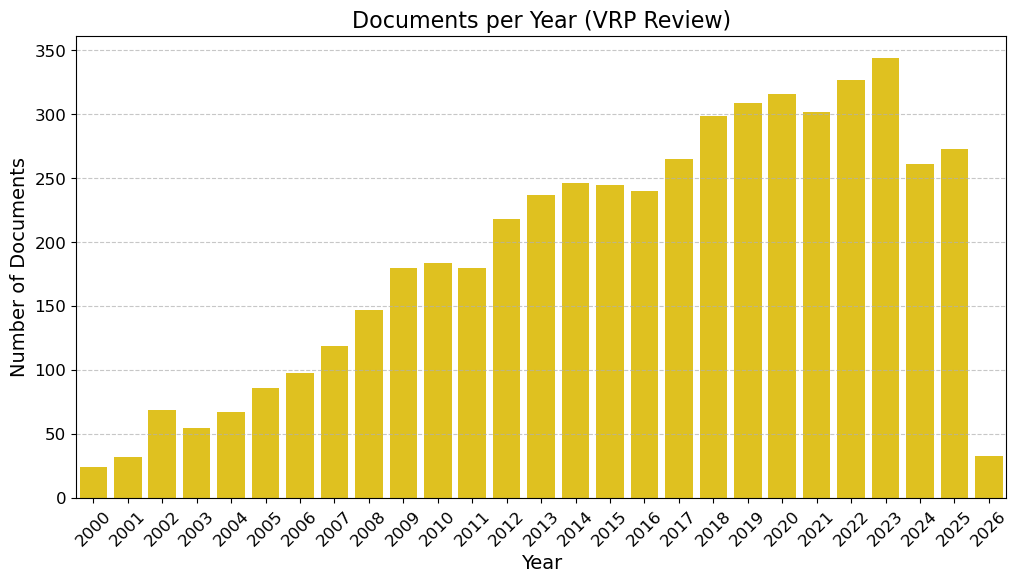

In [15]:

plot_production_trends(df_clean)


## Topic Analysis

/tmp/ipykernel_1554987/2377348178.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_real.values, y=top_10_real.index, palette='magma')


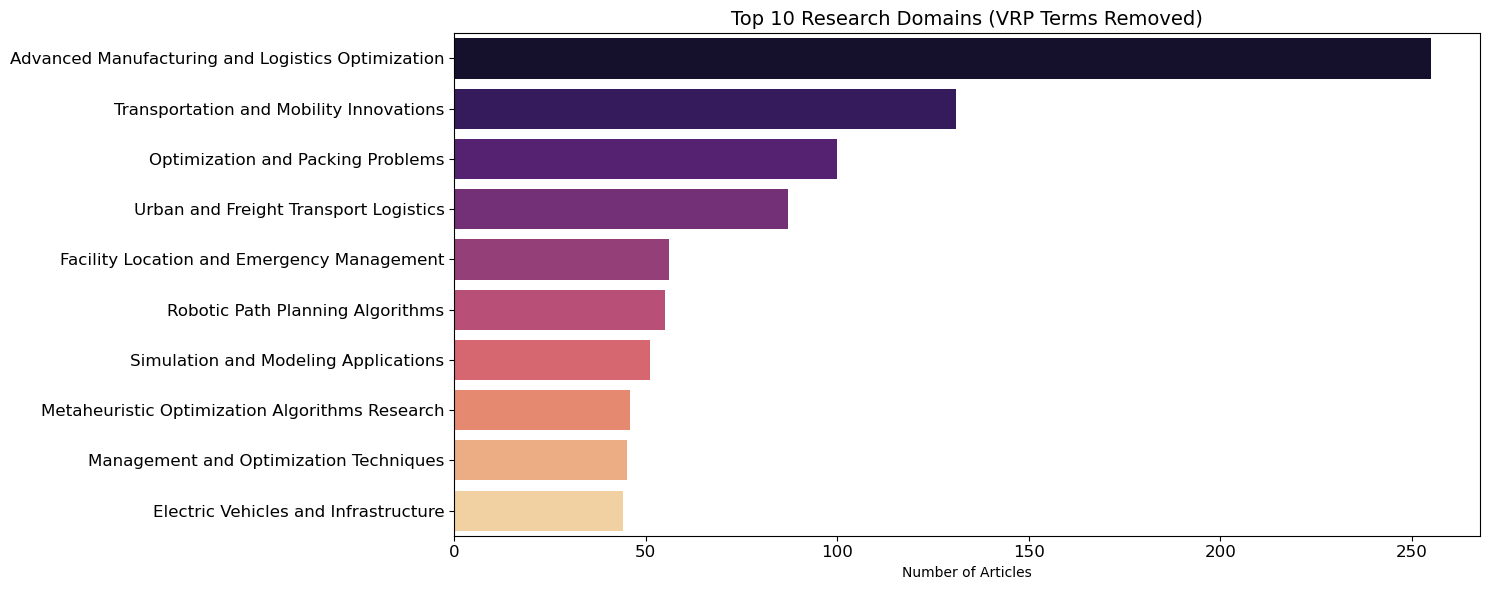

In [16]:

plot_real_trends(df_clean)

## Top Cited Articles

In [17]:

show_top_cited(df_clean)

,display_name,primary_author,publication_year,cited_by_count
153,The Vehicle Routing Problem,Paolo Toth,2002.0,3958
430,An Adaptive Large Neighborhood Search Heuristi...,Stefan Røpke,2006.0,2241
387,The vehicle routing problem An overview of exa...,Gilbert Laporte,1992.0,1705
696,The flying sidekick traveling salesman problem...,Chase Murray,2015.0,1464
0,A general heuristic for vehicle routing problems,David Pisinger,2005.0,1360
513,Using Constraint Programming and Local Search ...,Paul Shaw,1998.0,1282
1042,Handbook of Scheduling Algorithms Models and P...,Joseph Leung,2004.0,1225
603,The Electric Vehicle-Routing Problem with Time...,Michael Schneider,2014.0,1178
611,Vehicle Routing Problems for Drone Delivery,Kevin Dorling,2016.0,1173
359,The multiple traveling salesman problem an ove...,Tolga Bektaş,2005.0,1119


## Top Authors

### Per citations

In [18]:
top_authors_list = plot_top_authors(df_clean,10)

NameError: name 'plot_top_authors' is not defined

### Per publications

/tmp/ipykernel_1480527/3317235489.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pubs.values, y=top_pubs.index, palette='viridis')


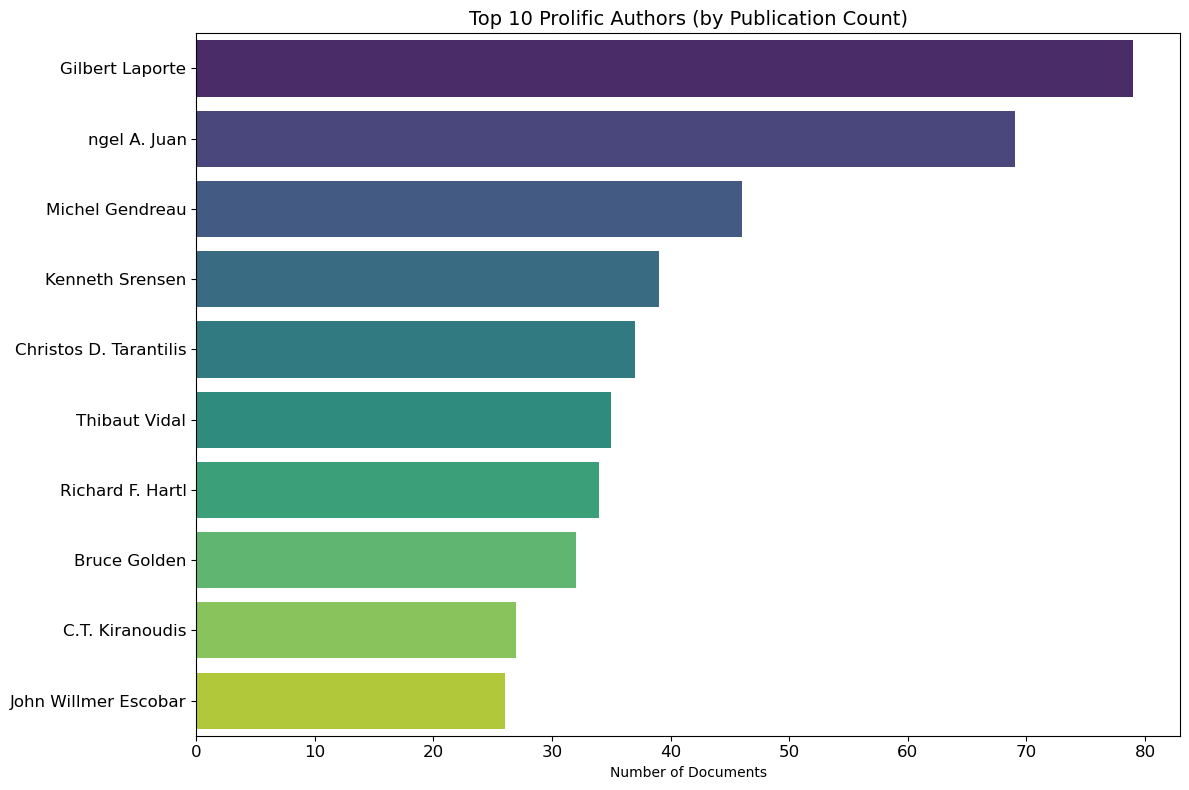

In [ ]:

top_prolific = plot_top_authors_by_pubs(df_clean, 10)

# Last 10 Years Results

In [ ]:
df_recent = filter_by_last_n_years(df_clean, 11)

# Verify the range
print(f"Minimum year in filtered set: {df_recent['publication_year'].min()}")

Original articles: 5422
Articles from 2015 to 2026: 3214
Minimum year in filtered set: 2015.0


In [ ]:
df_recent.head()

,id,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,cited_by_count,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,primary_author
7,https://openalex.org/W2927378423,David Sacramento|David Pisinger|Stefan Rpke,https://openalex.org/A5041840487|https://opena...,https://orcid.org/0000-0002-2155-2942|https://...,DK|DK|DK,Technical University of Denmark|Technical Univ...,https://openalex.org/I96673099|https://openale...,True|False|False,NaN,468,...,closed,Transportation Research Part C Emerging Techno...,https://openalex.org/S64511102,0968-090X,journal,Vehicle Routing Optimization Methods,2019-03-22,2019.0,article,David Sacramento
12,https://openalex.org/W3136908367,Wei Qin|Zilong Zhuang|Zizhao Huang|Haozhe Huang,https://openalex.org/A5054830882|https://opena...,https://orcid.org/0000-0002-8527-0354|https://...,CN|CN|CN|CN,Shanghai Jiao Tong University|Shanghai Jiao To...,https://openalex.org/I183067930|https://openal...,True|False|False|False,NaN,130,...,closed,Computers & Industrial Engineering,https://openalex.org/S196821226,0360-8352,journal,Vehicle Routing Optimization Methods,2021-03-23,2021.0,article,Wei Qin
13,https://openalex.org/W2996796639,Raafat Elshaer|Hadeer Awad,https://openalex.org/A5004291940|https://opena...,https://orcid.org/0000-0001-7112-4981|https://...,EG|EG,Zagazig University|Zagazig University,https://openalex.org/I192398990|https://openal...,True|False,NaN,283,...,closed,Computers & Industrial Engineering,https://openalex.org/S196821226,0360-8352,journal,Vehicle Routing Optimization Methods,2019-12-26,2019.0,review,Raafat Elshaer
16,https://openalex.org/W3111551443,Bra Olgun|ar Ko|Fulya Altparmak,https://openalex.org/A5004938821|https://opena...,|https://orcid.org/0000-0002-7377-204X|https:/...,TR|TR|TR,Süleyman Demirel University|Ankara University|...,https://openalex.org/I175124709|https://openal...,False|True|False,NaN,105,...,closed,Computers & Industrial Engineering,https://openalex.org/S196821226,0360-8352,journal,Vehicle Routing Optimization Methods,2020-12-08,2020.0,article,Büşra Olgun
34,https://openalex.org/W2226731518,ar Ko|smail Karaolan,https://openalex.org/A5058877968|https://opena...,https://orcid.org/0000-0002-7377-204X|https://...,CA|TR,HEC Montréal|Selçuk University,https://openalex.org/I108192572|https://openal...,True|False,NaN,207,...,closed,Applied Soft Computing,https://openalex.org/S140556538,1568-4946,journal,Vehicle Routing Optimization Methods,2015-11-21,2015.0,article,Çağrı Koç


## Topic Analysis

/tmp/ipykernel_1480527/2377348178.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_real.values, y=top_10_real.index, palette='magma')


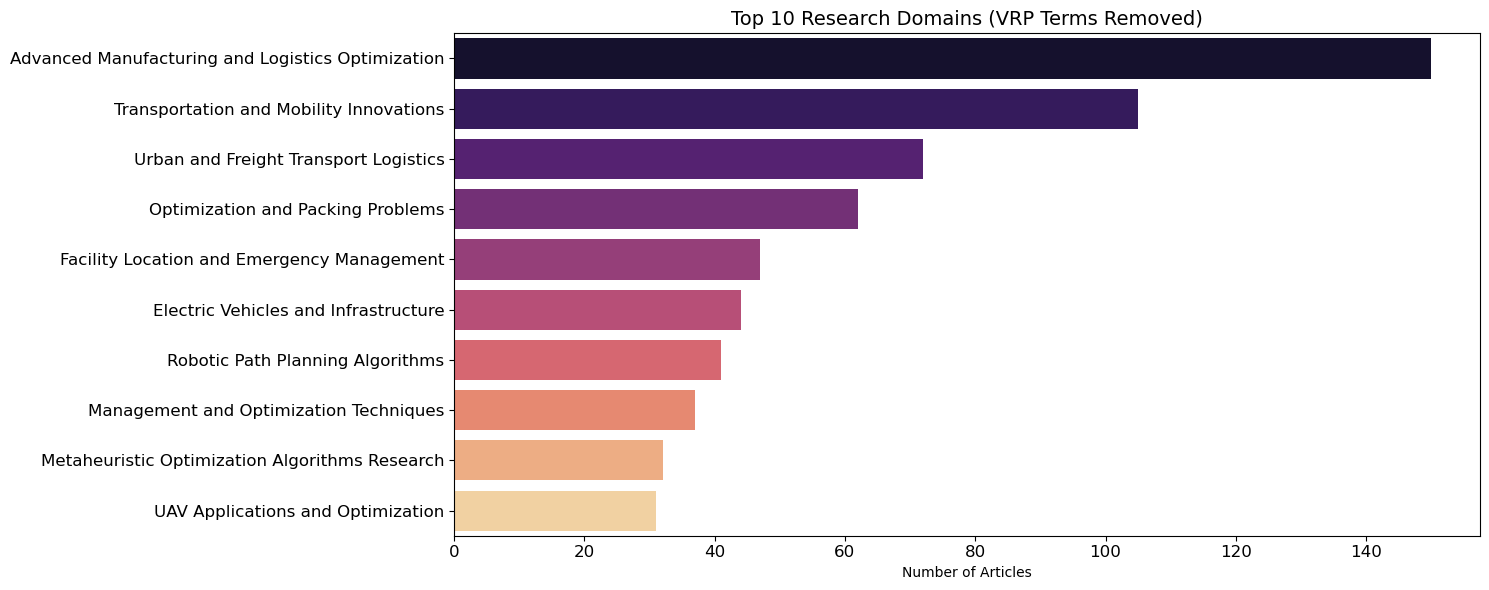

In [ ]:

plot_real_trends(df_recent)

## Top Cited Articles

In [ ]:

show_top_cited(df_recent)

,display_name,primary_author,publication_year,cited_by_count
696,The flying sidekick traveling salesman problem...,Chase Murray,2015.0,1464
611,Vehicle Routing Problems for Drone Delivery,Kevin Dorling,2016.0,1173
7,An adaptive large neighborhood search metaheur...,David Sacramento,2019.0,468
944,The Vehicle Routing Problem with Occasional Dr...,Claudia Archetti,2016.0,361
13,A taxonomic review of metaheuristic algorithms...,Raafat Elshaer,2019.0,283
691,A Survey on the Electric Vehicle Routing Probl...,Tomislav Erdelić,2019.0,251
794,Thirty years of heterogeneous vehicle routing,Çağrı Koç,2015.0,250
948,A hybrid VNSTabu search algorithm for solving ...,Daniel Schermer,2019.0,244
928,The electric vehicle routing problem with ener...,Samuel Pelletier,2019.0,239
1023,A parallel simulated annealing method for the ...,Chao Wang,2015.0,228


## Top Authors

### Per citations

/tmp/ipykernel_1501292/3487523125.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


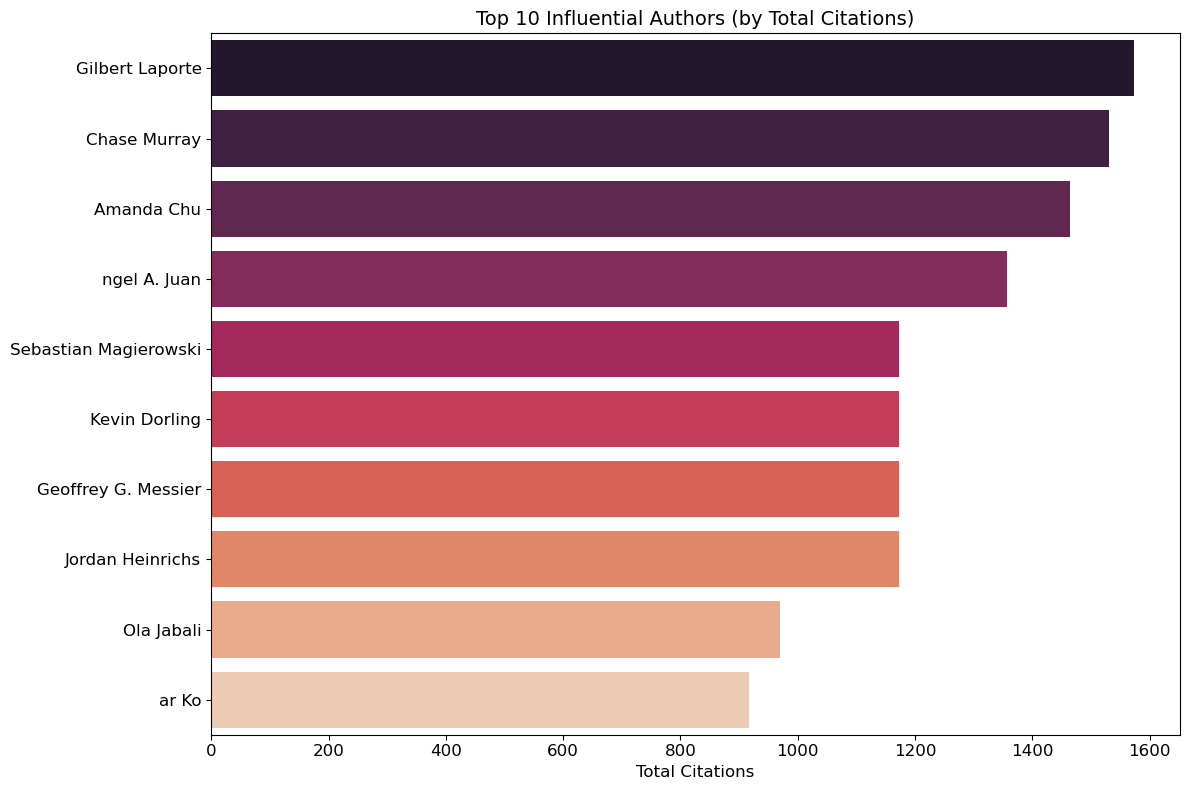

authorships.author.display_name
Gilbert Laporte          1573
Chase Murray             1531
Amanda Chu               1464
ngel A. Juan             1356
Sebastian Magierowski    1173
Kevin Dorling            1173
Geoffrey G. Messier      1173
Jordan Heinrichs         1173
Ola Jabali                970
ar Ko                     916
Name: cited_by_count, dtype: int64

In [ ]:
plot_top_stats(df_recent,category = 'author', metric='citations')

### Per publications

/tmp/ipykernel_1501292/3487523125.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


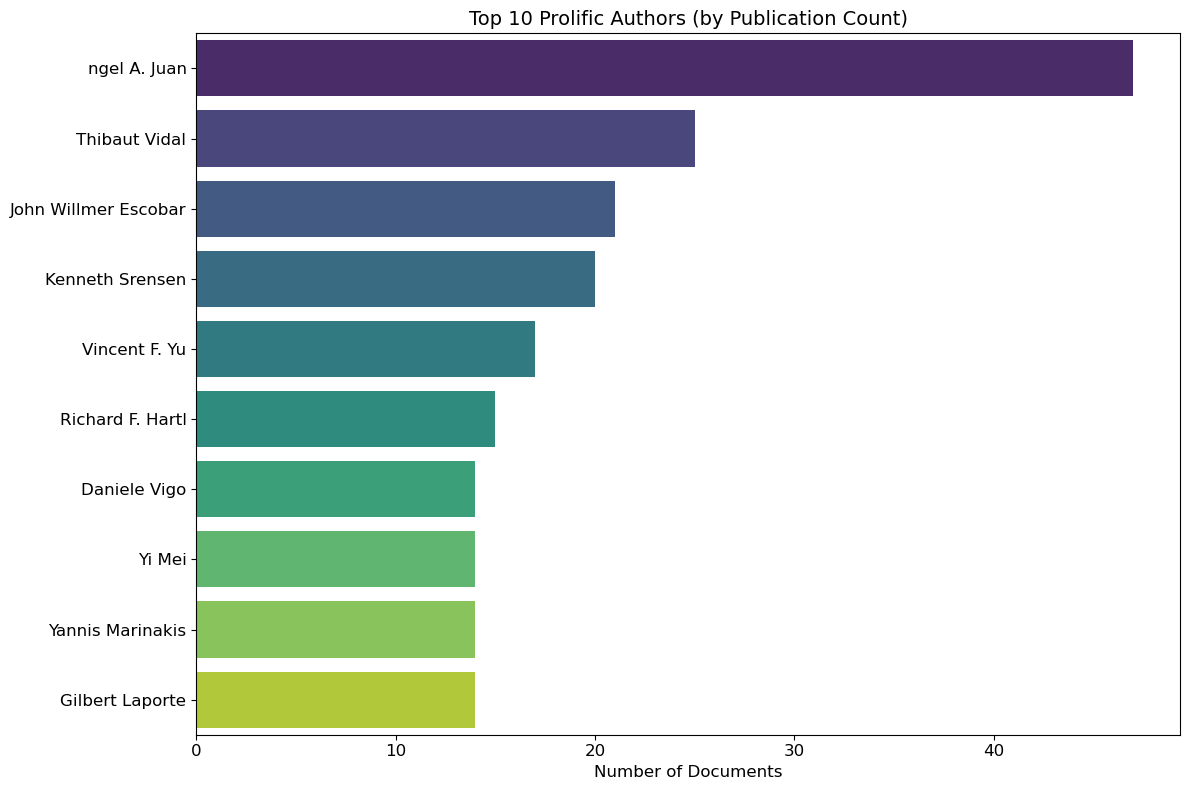

authorships.author.display_name
ngel A. Juan            47
Thibaut Vidal           25
John Willmer Escobar    21
Kenneth Srensen         20
Vincent F. Yu           17
Richard F. Hartl        15
Daniele Vigo            14
Yi Mei                  14
Yannis Marinakis        14
Gilbert Laporte         14
dtype: int64

In [ ]:
plot_top_stats(df_recent,category = 'author',metric='publications')

## Top Institutions

### Per citations

/tmp/ipykernel_1528290/3605809903.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


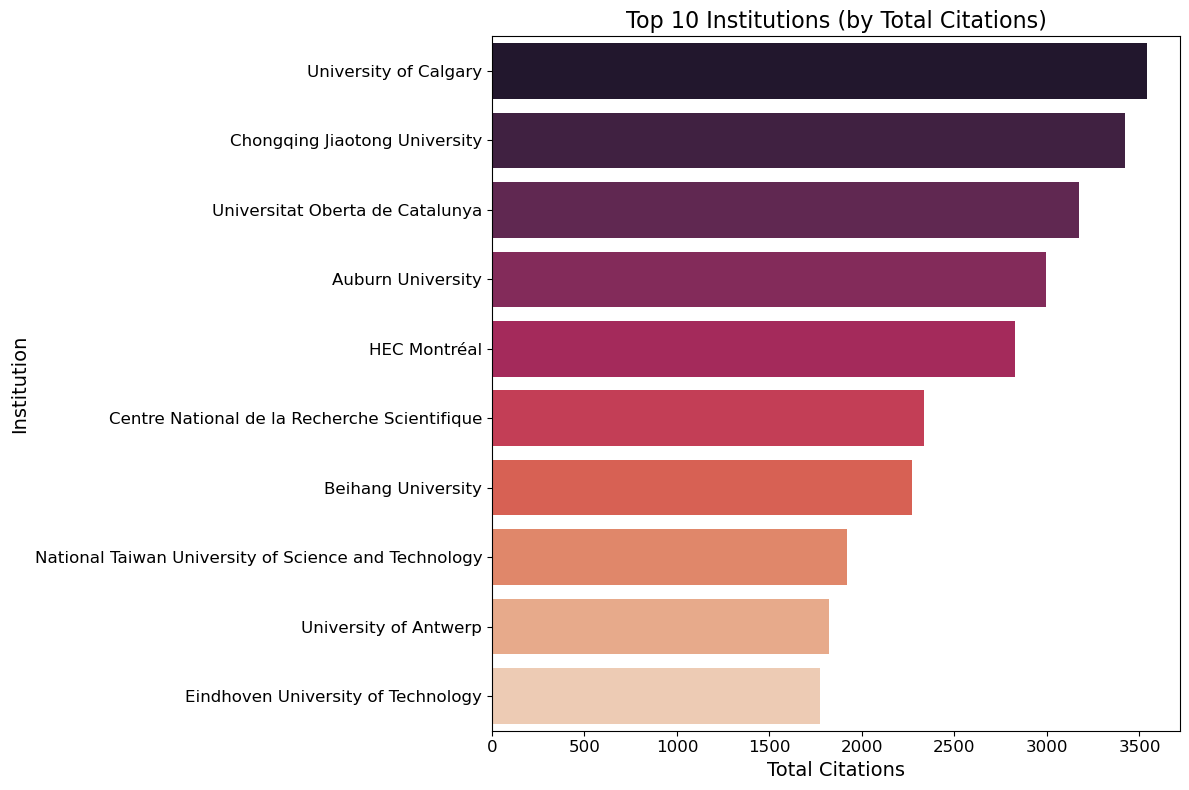

authorships.institutions.display_name
University of Calgary                                   3542
Chongqing Jiaotong University                           3423
Universitat Oberta de Catalunya                         3172
Auburn University                                       2995
HEC Montréal                                            2828
Centre National de la Recherche Scientifique            2333
Beihang University                                      2270
National Taiwan University of Science and Technology    1921
University of Antwerp                                   1824
Eindhoven University of Technology                      1775
Name: cited_by_count, dtype: int64

In [ ]:
plot_top_stats(df_recent,category = 'institution', metric='citations')

### Per Publications

/tmp/ipykernel_1501292/3487523125.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


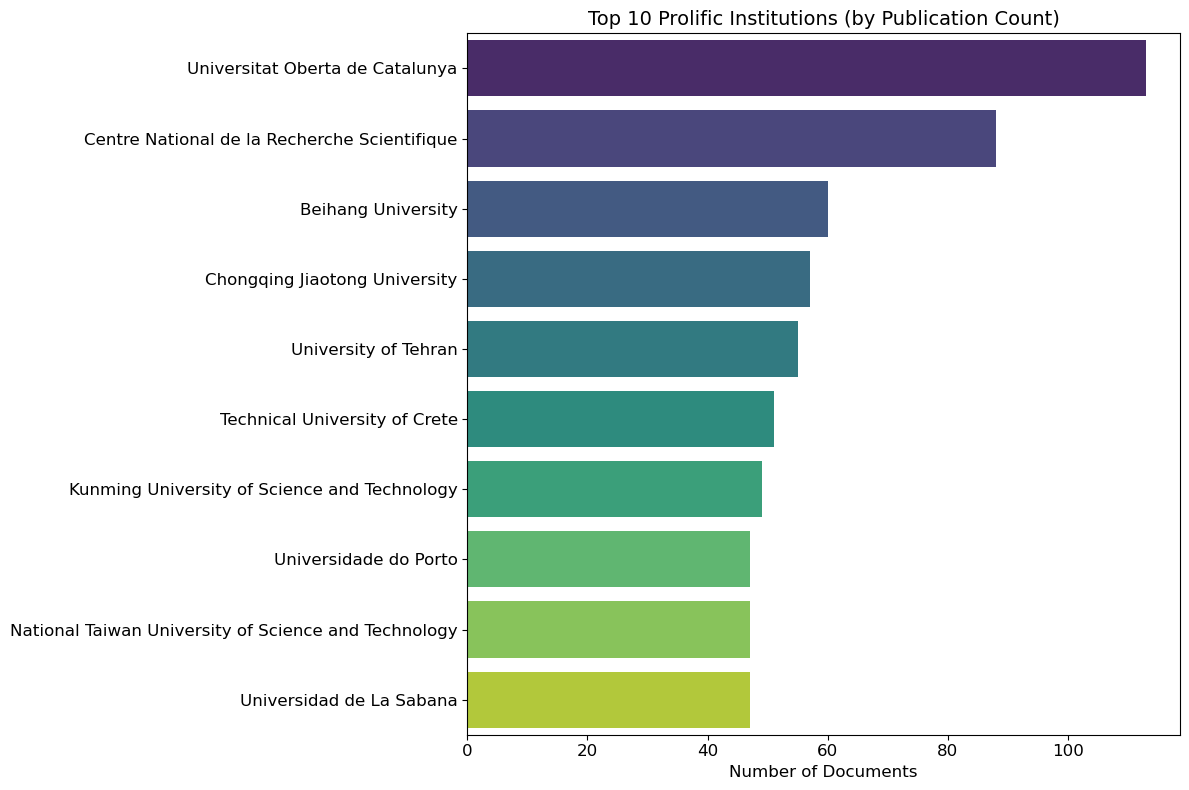

authorships.institutions.display_name
Universitat Oberta de Catalunya                         113
Centre National de la Recherche Scientifique             88
Beihang University                                       60
Chongqing Jiaotong University                            57
University of Tehran                                     55
Technical University of Crete                            51
Kunming University of Science and Technology             49
Universidade do Porto                                    47
National Taiwan University of Science and Technology     47
Universidad de La Sabana                                 47
dtype: int64

In [ ]:
plot_top_stats(df_recent,category = 'institution', metric='publications')

## Top Countries

### Per citations

/tmp/ipykernel_1528290/3605809903.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


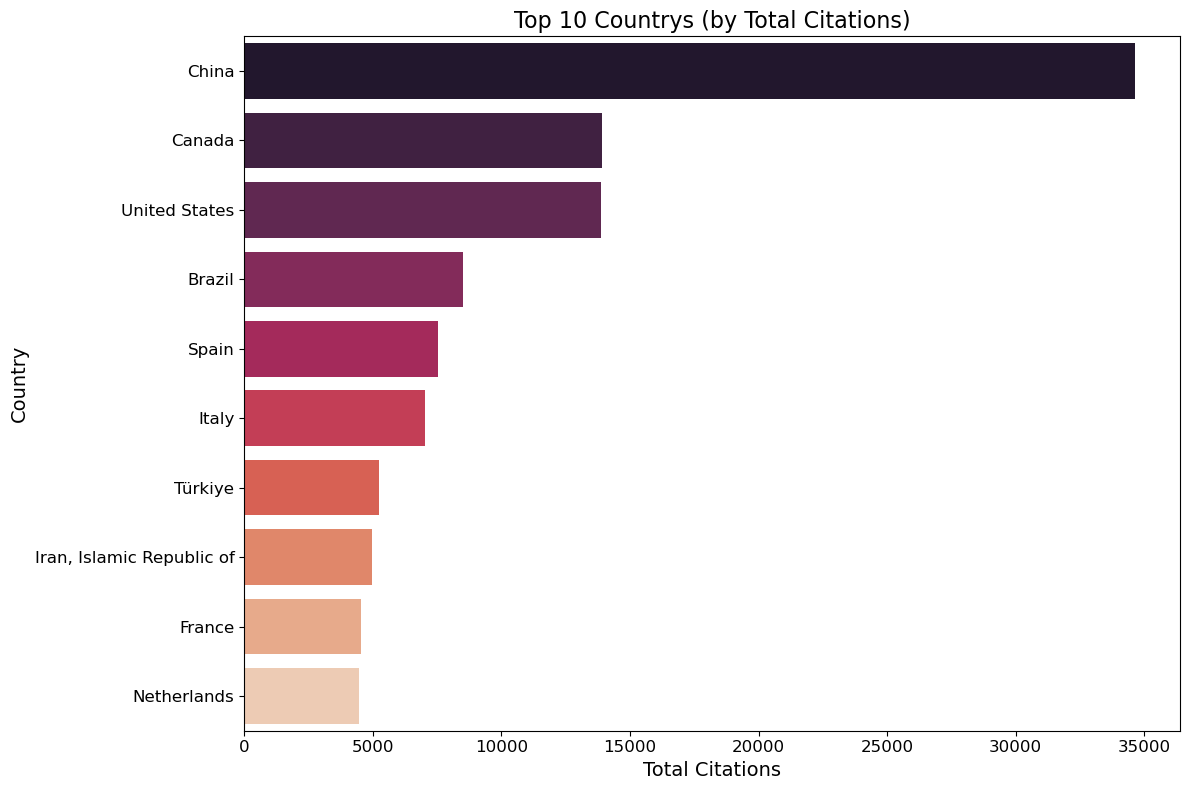

authorships.countries
China                        34655
Canada                       13895
United States                13856
Brazil                        8509
Spain                         7540
Italy                         7019
Türkiye                       5236
Iran, Islamic Republic of     4969
France                        4534
Netherlands                   4457
Name: cited_by_count, dtype: int64

In [ ]:
plot_top_stats(df_recent,category = 'country', metric='citations')

### Per publications

/tmp/ipykernel_1528290/3605809903.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


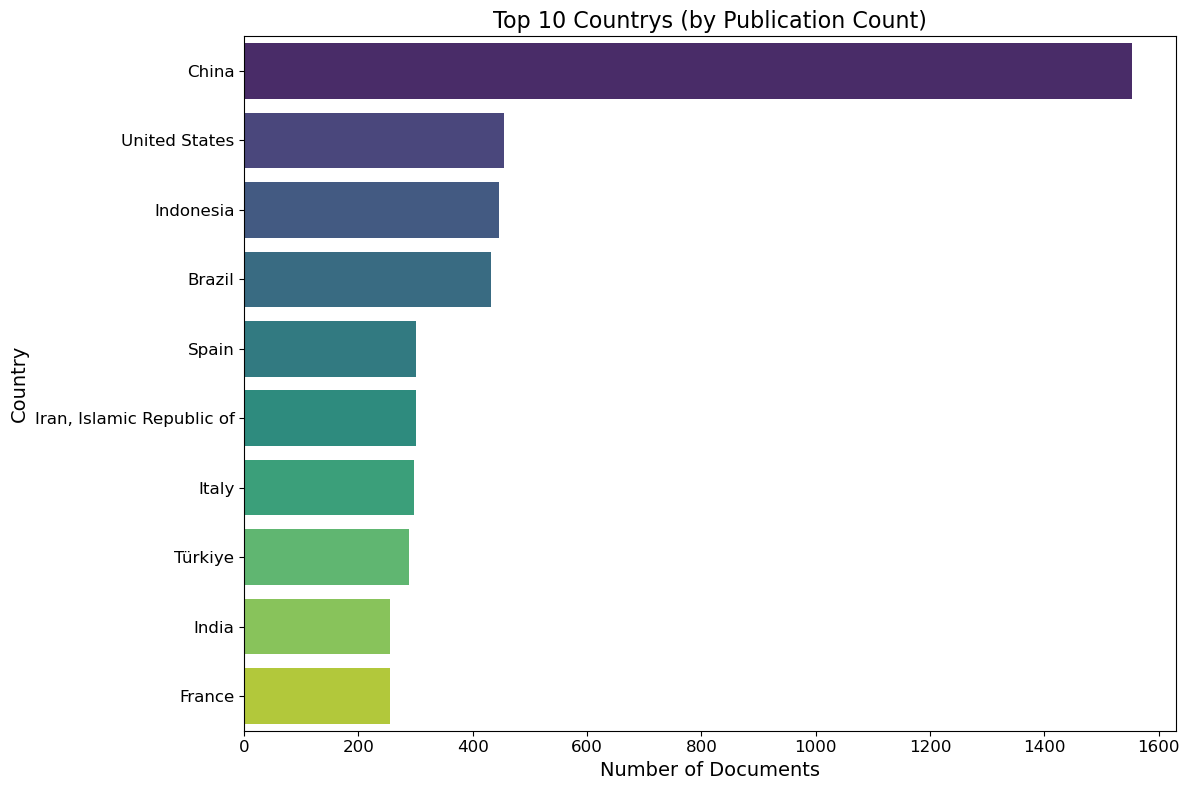

authorships.countries
China                        1553
United States                 455
Indonesia                     445
Brazil                        432
Spain                         301
Iran, Islamic Republic of     300
Italy                         297
Türkiye                       289
India                         256
France                        255
dtype: int64

In [ ]:
plot_top_stats(df_recent,category = 'country', metric='publications')

## Colaborations

Showing top 6 author clusters.


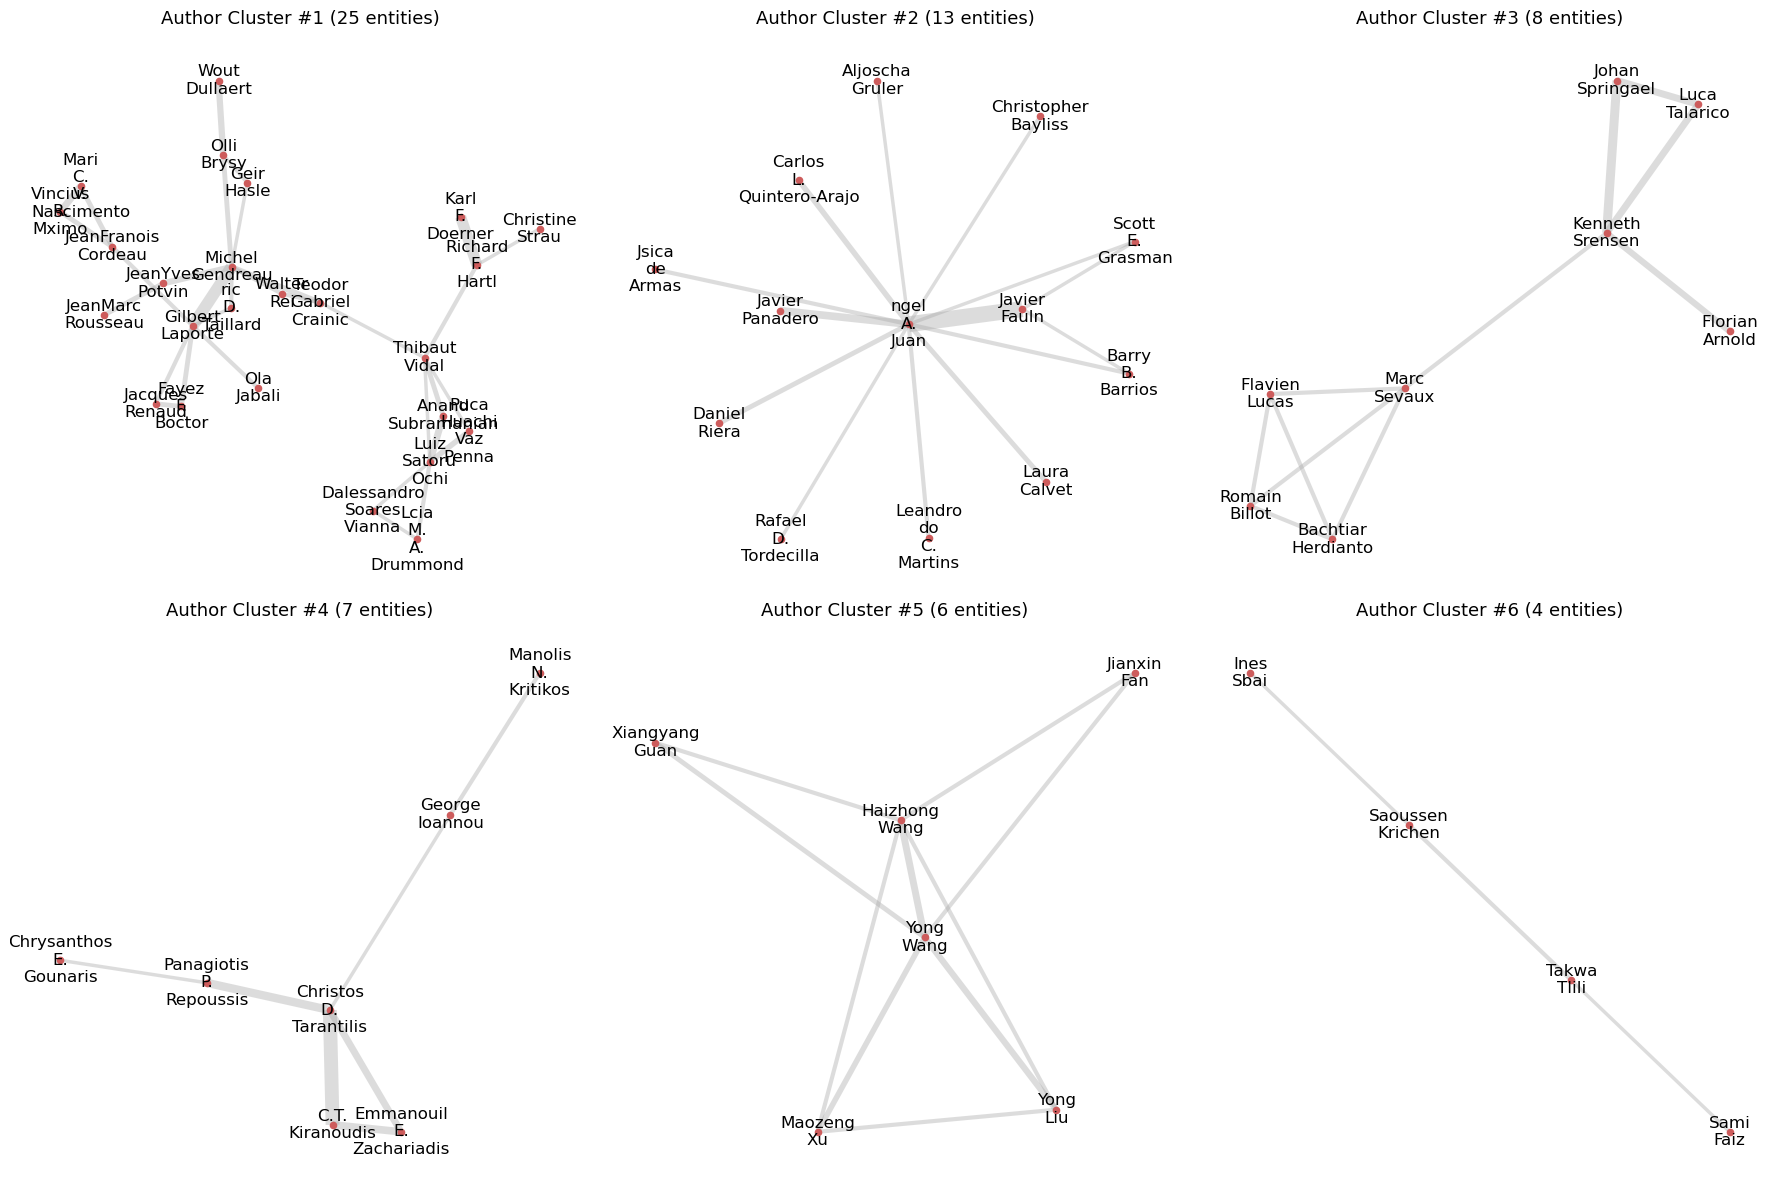

In [ ]:
analyze_category_clusters(df_clean, category='author', min_shared=5, grid_rows=2, grid_cols=3,font_size=12)

Showing top 1 country clusters.


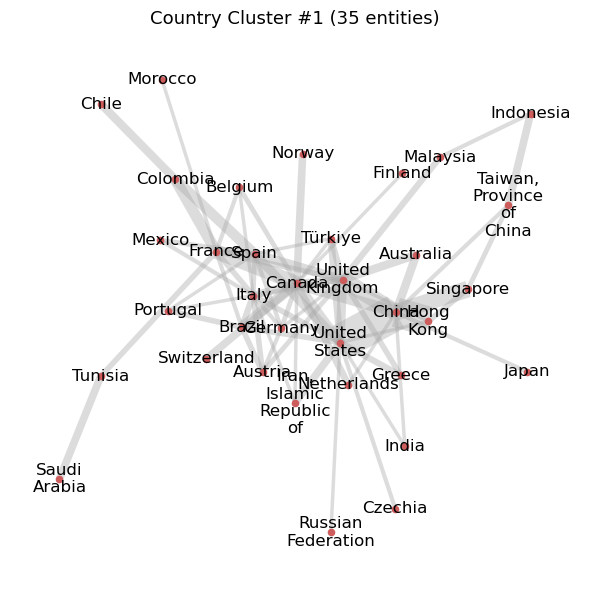

In [ ]:

# --- Example Usages ---
analyze_category_clusters(df_clean, category='country', min_shared=5, grid_rows=1, grid_cols=1)

Showing top 4 institution clusters.


/tmp/ipykernel_1528290/3356038994.py:78: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.



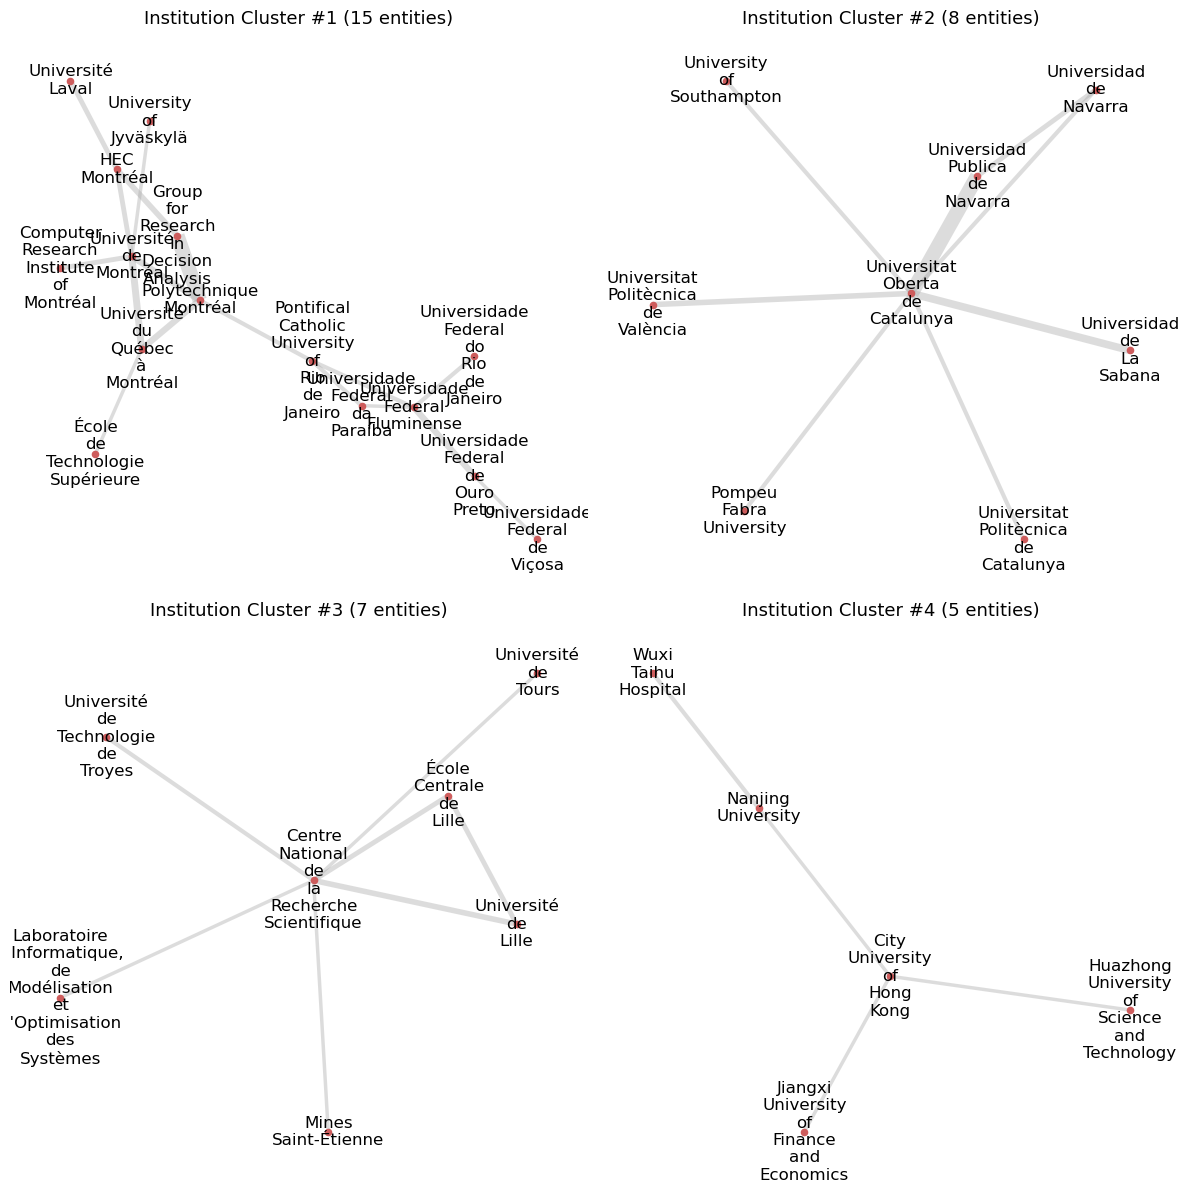

In [ ]:
analyze_category_clusters(df_clean, category='institution', min_shared=5, grid_rows=2, grid_cols=2)